The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\mxm\AppData\Local\Temp\ipykernel_27228\3648535649.py:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3, 3)); plt.imshow((blurry_image1 * 255).astype(np.uint8)); plt.title(f'{pair_name}: blurry image1'); plt.axis('off')


Writeup images generated for required 5 pairs.


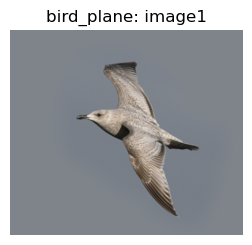

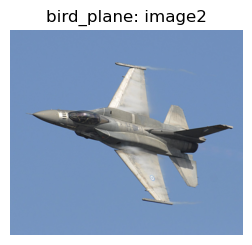

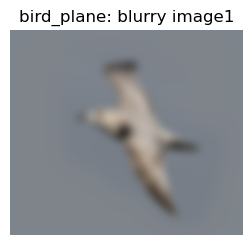

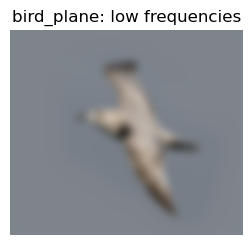

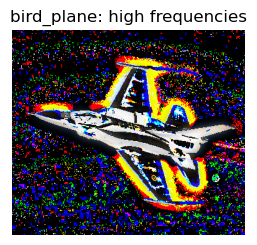

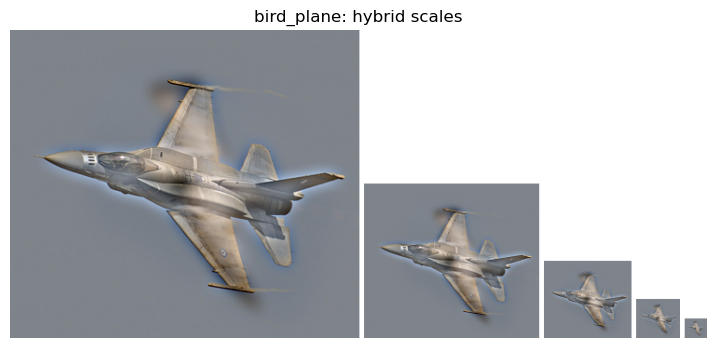

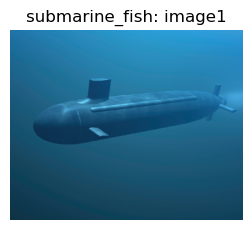

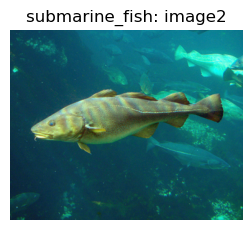

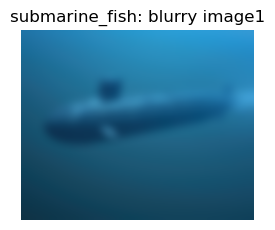

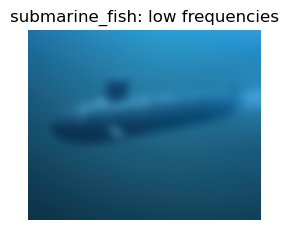

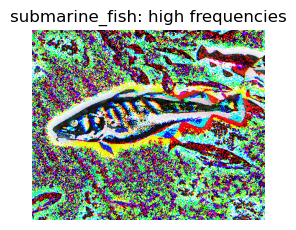

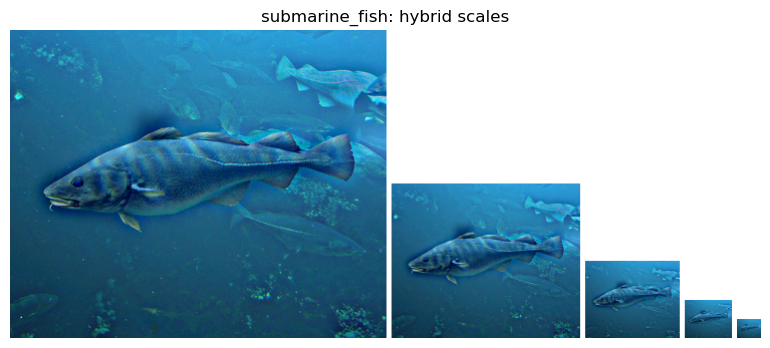

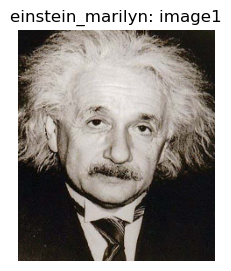

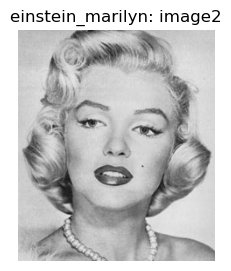

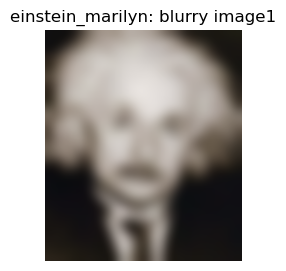

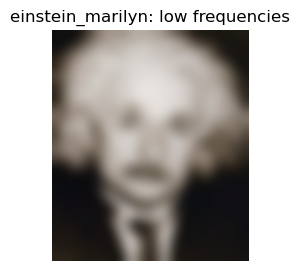

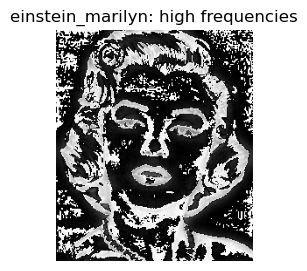

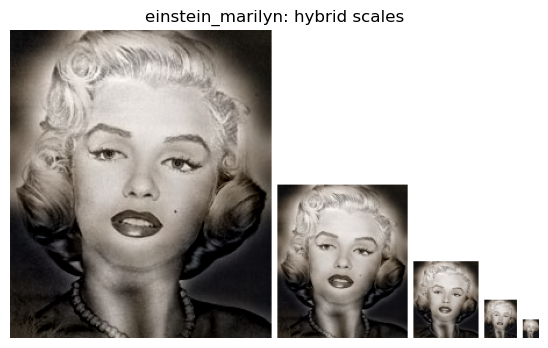

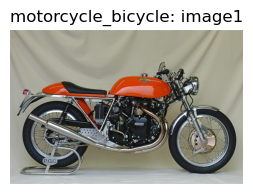

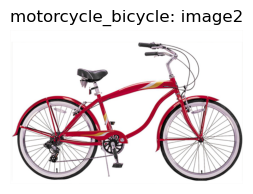

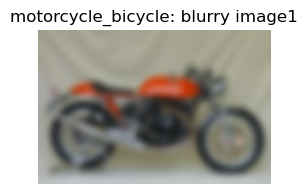

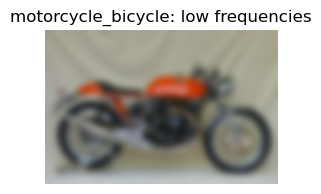

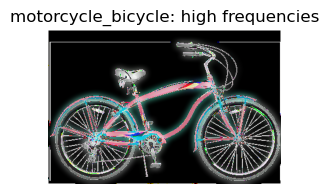

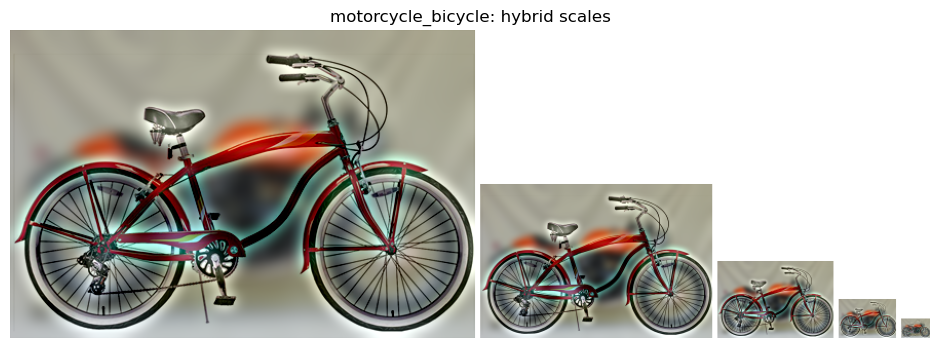

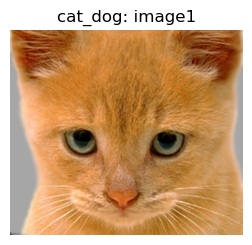

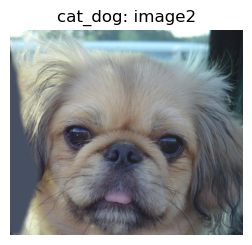

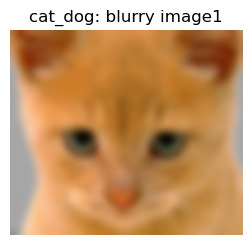

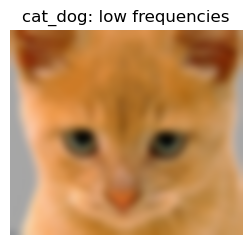

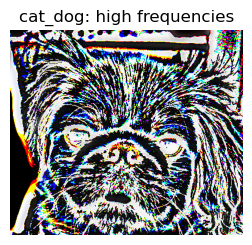

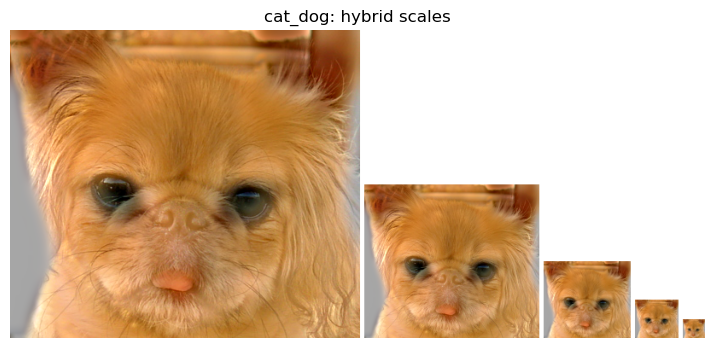

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from utils import vis_hybrid_image, load_image, save_image
from student_code import my_imfilter, create_hybrid_image
%load_ext autoreload
%autoreload 2

WRITEUP_IMAGE_PATHS = {
    'bird': '../data/bird.bmp',
    'plane': '../data/plane.bmp',
    'submarine': '../data/submarine.bmp',
    'fish': '../data/fish.bmp',
    'einstein': '../data/einstein.bmp',
    'marilyn': '../data/marilyn.bmp',
    'motorcycle': '../data/motorcycle.bmp',
    'bicycle': '../data/bicycle.bmp',
    'cat': '../data/cat.bmp',
    'dog': '../data/dog.bmp',
}

WRITEUP_PAIRS = [
    ('bird', 'plane'),
    ('submarine', 'fish'),
    ('einstein', 'marilyn'),
    ('motorcycle', 'bicycle'),
    ('cat', 'dog'),
]


cutoff_frequency = 7
filter = cv2.getGaussianKernel(ksize=cutoff_frequency * 4 + 1, sigma=cutoff_frequency)
filter = np.dot(filter, filter.T)

output_root = '../results/writeup_hybrid_examples'
os.makedirs(output_root, exist_ok=True)

def resize_to_match(image_ref, image_to_resize):
    h, w = image_ref.shape[:2]
    return cv2.resize(image_to_resize, (w, h), interpolation=cv2.INTER_LINEAR)

def run_one_pair(name1, name2, root):
    image1 = load_image(WRITEUP_IMAGE_PATHS[name1])
    image2 = load_image(WRITEUP_IMAGE_PATHS[name2])
    if image1.shape != image2.shape:
        image2 = resize_to_match(image1, image2)
    blurry_image1 = my_imfilter(image1, filter)
    low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, filter)
    vis = vis_hybrid_image(hybrid_image)
    pair_name = f'{name1}_{name2}'
    pair_dir = os.path.join(root, pair_name)
    os.makedirs(pair_dir, exist_ok=True)
    plt.figure(figsize=(3, 3)); plt.imshow((image1 * 255).astype(np.uint8)); plt.title(f'{pair_name}: image1'); plt.axis('off')
    plt.figure(figsize=(3, 3)); plt.imshow((image2 * 255).astype(np.uint8)); plt.title(f'{pair_name}: image2'); plt.axis('off')
    plt.figure(figsize=(3, 3)); plt.imshow((blurry_image1 * 255).astype(np.uint8)); plt.title(f'{pair_name}: blurry image1'); plt.axis('off')
    plt.figure(figsize=(3, 3)); plt.imshow((low_frequencies * 255).astype(np.uint8)); plt.title(f'{pair_name}: low frequencies'); plt.axis('off')
    plt.figure(figsize=(3, 3)); plt.imshow((high_frequencies * 255).astype(np.uint8)); plt.title(f'{pair_name}: high frequencies'); plt.axis('off')
    plt.figure(figsize=(12, 4)); plt.imshow(vis); plt.title(f'{pair_name}: hybrid scales'); plt.axis('off')
    save_image(os.path.join(pair_dir, 'low_frequencies.jpg'), low_frequencies)
    save_image(os.path.join(pair_dir, 'high_frequencies.jpg'), high_frequencies)
    save_image(os.path.join(pair_dir, 'hybrid_image.jpg'), hybrid_image)
    save_image(os.path.join(pair_dir, 'hybrid_image_scales.jpg'), vis)

for name1, name2 in WRITEUP_PAIRS:
    run_one_pair(name1, name2, output_root)


print('Writeup images generated for required 5 pairs.')

# Writeup: Hybrid Images (Non-Extra-Credit + Extra Credit)

本部分使用固定参数 cutoff_frequency = 7，按照课程示例流程（高斯低通 + 高频残差 + 融合）完成主实验 5 组结果，并额外给出 1 组 extra credit 结果。

## 主实验结果（5 组）

### 1) bird + plane
- 结果图：
![bird_plane](../results/writeup_hybrid_examples/bird_plane/hybrid_image_scales.jpg)

- 观察：整体上飞机结构占主导，边缘非常明显；随着尺度减小，机身轮廓更稳定。

### 2) submarine + fish
- 结果图：
![submarine_fish](../results/writeup_hybrid_examples/submarine_fish/hybrid_image_scales.jpg)

- 观察：近看鱼体纹理和轮廓清楚，远看水下整体结构更自然，尺度切换平滑。

### 3) einstein + marilyn
- 结果图：
![einstein_marilyn](../results/writeup_hybrid_examples/einstein_marilyn/hybrid_image_scales.jpg)

- 观察：近看能感到更强的人脸细节，远看更偏向平滑的人脸整体结构。

### 4) motorcycle + bicycle
- 结果图：
![motorcycle_bicycle](../results/writeup_hybrid_examples/motorcycle_bicycle/hybrid_image_scales.jpg)

- 观察：车轮辐条与车架线条在近看时细节丰富，远看保留了清晰的自行车大轮廓。

### 5) cat + dog
- 结果图：
![cat_dog](../results/writeup_hybrid_examples/cat_dog/hybrid_image_scales.jpg)

- 观察：近看时能看到狗的五官与毛发细节，远看时猫的整体轮廓更容易被感知。


## 总结
- 主实验 5 组：bird_plane、submarine_fish、einstein_marilyn、motorcycle_bicycle、cat_dog。
- submarine_fish、einstein_marilyn、cat_dog 的远近切换最自然。